<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/Cats_vs_Dogs_DeepLearning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐶🐱 Cats vs Dogs Classification using Deep Learning
## MIDTERM 2 PROJECT

Бұл жобада Deep Learning көмегімен мысық пен ит суреттерін классификациялайтын модель жасалады.
Жобада екі түрлі модель қолданылады:
1. Custom CNN
2. MobileNetV2 (Transfer Learning)

Соңында модельдердің нәтижелері салыстырылады.

In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import zipfile

with zipfile.ZipFile('/content/Dog.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset Extracted Successfully!")


Dataset Extracted Successfully!


## 📌 1. Import Libraries
Бұл бөлімде жобаға қажетті кітапханалар импортталады.

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📌 2. Upload Dataset
ZIP файлды Google Colab-қа upload жасаймыз.

## 📌 3. Extract ZIP File
Dataset-ті ашу.

## 📌 4. Dataset Path

In [3]:
cat_path = "/content/Cat"
dog_path = "/content/Dog"


## 📌 5. Load Images
Суреттерді оқып, resize және preprocessing жасаймыз.

In [4]:
IMG_SIZE = 64

data = []
labels = []

def load_images(folder, label):

    count = 0

    for img_name in os.listdir(folder):

        if count >= 3000:
            break

        img_path = os.path.join(folder, img_name)

        try:
            img = cv2.imread(img_path)

            if img is not None:

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                data.append(img)
                labels.append(label)

                count += 1

        except:
            pass

load_images(cat_path, 0)
load_images(dog_path, 1)

X = np.array(data, dtype='float32') / 255.0
y = np.array(labels)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (6000, 64, 64, 3)
y Shape: (6000,)


## 📌 6. Convert to NumPy Arrays

In [ ]:
X = np.array(data) / 255.0
y = np.array(labels)

print("X Shape:", X.shape)
print("y Shape:", y.shape)


## 📌 7. Exploratory Data Analysis (EDA)
Class distribution және sample images көрсетіледі.

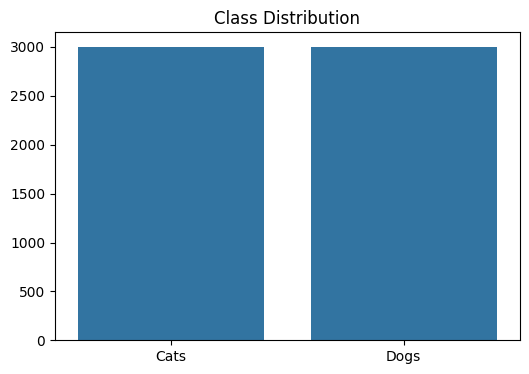

Cats: 3000
Dogs: 3000


In [5]:
cat_count = np.sum(y == 0)
dog_count = np.sum(y == 1)

plt.figure(figsize=(6,4))

sns.barplot(x=["Cats", "Dogs"], y=[cat_count, dog_count])

plt.title("Class Distribution")

plt.show()

print("Cats:", cat_count)
print("Dogs:", dog_count)


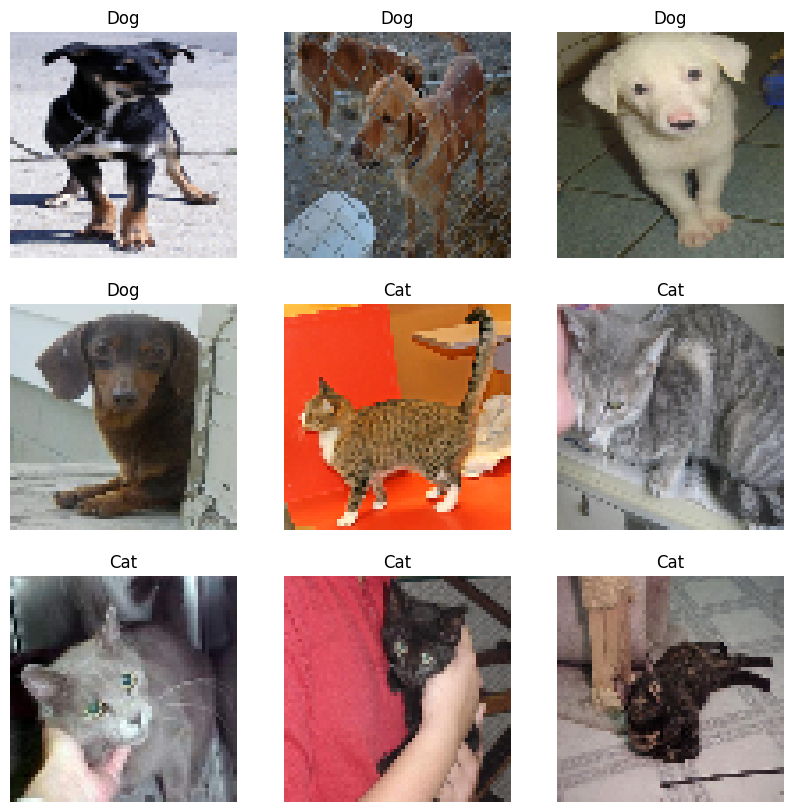

In [6]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    idx = np.random.randint(0, len(X))

    plt.imshow(X[idx])

    plt.title("Dog" if y[idx] == 1 else "Cat")

    plt.axis("off")

plt.show()


## 📌 8. Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (4800, 64, 64, 3)
Test Shape: (1200, 64, 64, 3)


## 📌 9. Data Augmentation

In [8]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)


## 📌 10. Model 1 — Custom CNN

In [11]:
cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 📌 11. Train CNN Model

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.5244 - loss: 0.6912 - val_accuracy: 0.5283 - val_loss: 0.6876
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.5667 - loss: 0.6765 - val_accuracy: 0.6208 - val_loss: 0.6830
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.6429 - loss: 0.6438 - val_accuracy: 0.5825 - val_loss: 0.6581
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.6654 - loss: 0.6097 - val_accuracy: 0.6958 - val_loss: 0.5854
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.6867 - loss: 0.5859 - val_accuracy: 0.7083 - val_loss: 0.5706
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.7179 - loss: 0.5638 - val_accuracy: 0.7025 - val_loss: 0.5614
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.7298 - loss: 0.5364 - val_accuracy: 0.7275 - val_loss: 0.5334
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.7590 - loss: 0.5085 - val_ac

## 📌 12. Evaluate CNN Model

In [13]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    X_test,
    y_test
)

print("CNN Accuracy:", cnn_acc)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7567 - loss: 0.5136
CNN Accuracy: 0.7566666603088379


## 📌 13. Accuracy and Loss Graphs

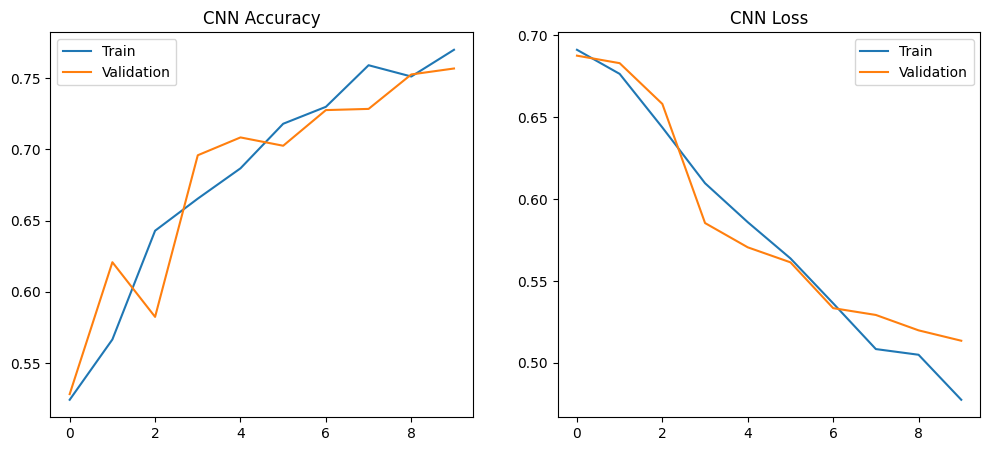

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Accuracy")

plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)

plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("CNN Loss")

plt.legend(["Train", "Validation"])

plt.show()


## 📌 14. Confusion Matrix

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


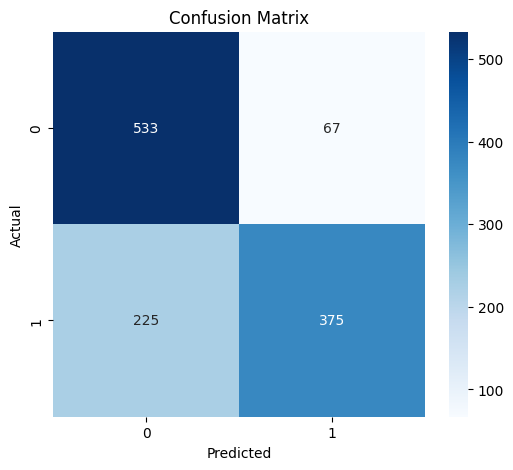

              precision    recall  f1-score   support

           0       0.70      0.89      0.78       600
           1       0.85      0.62      0.72       600

    accuracy                           0.76      1200
   macro avg       0.78      0.76      0.75      1200
weighted avg       0.78      0.76      0.75      1200



In [15]:
y_pred = cnn_model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, y_pred))


## 📌 15. Model 2 — MobileNetV2

In [19]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

base_model.trainable = False

mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

/tmp/ipykernel_7030/2084259916.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 📌 16. Train MobileNetV2

In [20]:
history_mobile = mobilenet_model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.7358 - loss: 0.5476 - val_accuracy: 0.7967 - val_loss: 0.4220
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7812 - loss: 0.4580 - val_accuracy: 0.8150 - val_loss: 0.3911
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7973 - loss: 0.4319 - val_accuracy: 0.8092 - val_loss: 0.3906
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7983 - loss: 0.4245 - val_accuracy: 0.8167 - val_loss: 0.3832
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8152 - loss: 0.4076 - val_accuracy: 0.8242 - val_loss: 0.4043


## 📌 17. Evaluate MobileNetV2

In [21]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(
    X_test,
    y_test
)

print("MobileNetV2 Accuracy:", mobile_acc)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8167 - loss: 0.3832
MobileNetV2 Accuracy: 0.8166666626930237


## 📌 18. Compare Models

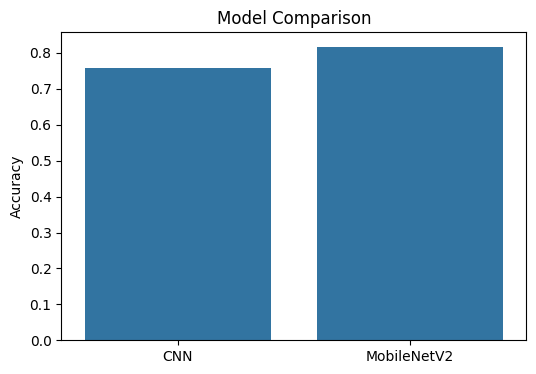

CNN Accuracy: 0.7566666603088379
MobileNetV2 Accuracy: 0.8166666626930237


In [22]:
models = ["CNN", "MobileNetV2"]

accuracies = [cnn_acc, mobile_acc]

plt.figure(figsize=(6,4))

sns.barplot(
    x=models,
    y=accuracies
)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

print("CNN Accuracy:", cnn_acc)
print("MobileNetV2 Accuracy:", mobile_acc)


## 📌 19. Save Models

In [23]:
cnn_model.save("cnn_model.h5")

mobilenet_model.save("mobilenet_model.h5")

print("Models Saved Successfully")


Models Saved Successfully


## 📌 20. Final Conclusion

In [ ]:
print('''

Project Completed Successfully!

Models Used:
1. Custom CNN
2. MobileNetV2

Result:
MobileNetV2 achieved better accuracy
than the custom CNN model.

''')
